In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from torch import device, cuda, tensor, float32,load
from torch.utils.data import Dataset,DataLoader
from torchvision.utils import make_grid
from torchvision.models import densenet121,resnet50,efficientnet_v2_m,vit_b_16,swin_v2_t,DenseNet121_Weights,ResNet50_Weights,EfficientNet_V2_M_Weights,ViT_B_16_Weights,Swin_V2_T_Weights
import torchvision.transforms as transforms
from PIL import Image

from sklearn.metrics import roc_auc_score
from warnings import filterwarnings
filterwarnings("ignore")

%matplotlib inline

dev = device("cuda" if cuda.is_available() else "cpu")
dev

device(type='cuda')

In [ ]:
checkpoint = load("data_essentials.pth",map_location=dev,weights_only=False)
checkpoint.keys()

dict_keys(['train_df', 'val_df', 'test_df', 'all_diseases', 'img_folders', 'num_of_classes', 'pos_weights'])

In [ ]:

IMG_FOLDERS = checkpoint["img_folders"]

NUM_OF_CLASSES = checkpoint["num_of_classes"]

ALL_DISEASES = checkpoint["all_diseases"]

BATCH_SIZE = 32
MEAN_NORM = [0.485, 0.456, 0.406]
STD_NORM = [0.229, 0.224, 0.225]

POS_WEIGHTS = checkpoint["pos_weights"]

LR = 1e-4

train_df = checkpoint["train_df"]
val_df = checkpoint["val_df"]
test_df = checkpoint["test_df"]

In [ ]:
def get_transforms(size=224 , In_Train=True):
    if In_Train:
        return transforms.Compose([transforms.Resize((size,size)),
                                   transforms.RandomRotation(10),
                                   transforms.RandomHorizontalFlip(),
                                   transforms.ColorJitter(brightness=0.1, contrast=0.1),
                                   transforms.ToTensor(),
                                   transforms.Normalize(mean=MEAN_NORM,
                                                        std=STD_NORM)])
    else:
        return transforms.Compose([transforms.Resize((size,size)),
                                   transforms.ToTensor(),
                                   transforms.Normalize(mean=MEAN_NORM,
                                                        std=STD_NORM)])

In [ ]:
class ChestXRayDataset(Dataset):
    def __init__(self,df,img_folders,transforms=None):
        self.df = df.reset_index(drop=True)
        self.img_folders = img_folders
        self.transforms = transforms
        self.labels = self._encode_labels()

    def _encode_labels(self):
        encode = []

        for label in self.df["Finding Labels"]:
            diseases_in_img = label.split("|")

            vector = [0.0] * NUM_OF_CLASSES
            for disease in diseases_in_img:
                if disease in ALL_DISEASES:
                    idx = ALL_DISEASES.index(disease)
                    vector[idx] = 1.0
            encode.append(vector)
        return encode
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, index):
        img_name = self.df.loc[index,"Image Index"]

        img = None
        for folder in IMG_FOLDERS:
            img_path = os.path.join(folder,img_name)
            if os.path.exists(img_path):
                img = Image.open(img_path).convert("RGB")
                break
        
        if self.transforms:
            img = self.transforms(img)

        label = tensor(self.labels[index],dtype=float32)
        return img,label


train_dataset = ChestXRayDataset(train_df,IMG_FOLDERS,transforms=get_transforms())
val_dataset = ChestXRayDataset(val_df,IMG_FOLDERS,get_transforms(In_Train=False))
test_dataset = ChestXRayDataset(test_df,IMG_FOLDERS,get_transforms(In_Train=False))

eff_train_dataset = ChestXRayDataset(train_df,IMG_FOLDERS,get_transforms(384))
eff_val_dataset = ChestXRayDataset(val_df,IMG_FOLDERS,get_transforms(384,In_Train=False))
eff_test_dataset = ChestXRayDataset(test_df,IMG_FOLDERS,get_transforms(384,In_Train=False))

swin_train_dataset = ChestXRayDataset(train_df,IMG_FOLDERS,get_transforms(256))
swin_val_dataset = ChestXRayDataset(val_df,IMG_FOLDERS,get_transforms(256,In_Train=False))
swin_test_dataset = ChestXRayDataset(test_df,IMG_FOLDERS,get_transforms(256,In_Train=False))

In [ ]:
train_dl = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=8, pin_memory=True)
val_dl = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=8, pin_memory=True)
test_dl = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=8, pin_memory=True)

eff_train_dl = DataLoader(eff_train_dataset, batch_size=32, shuffle=True, num_workers=8, pin_memory=True)
eff_val_dl = DataLoader(eff_val_dataset, batch_size=32, shuffle=False, num_workers=8, pin_memory=True)
eff_test_dl = DataLoader(eff_test_dataset, batch_size=32, shuffle=False, num_workers=8, pin_memory=True)

swin_train_dl = DataLoader(swin_train_dataset, batch_size=32, shuffle=True, num_workers=8, pin_memory=True)
swin_val_dl = DataLoader(swin_val_dataset, batch_size=32, shuffle=False, num_workers=8, pin_memory=True)
swin_test_dl = DataLoader(swin_test_dataset, batch_size=32, shuffle=False, num_workers=8, pin_memory=True)

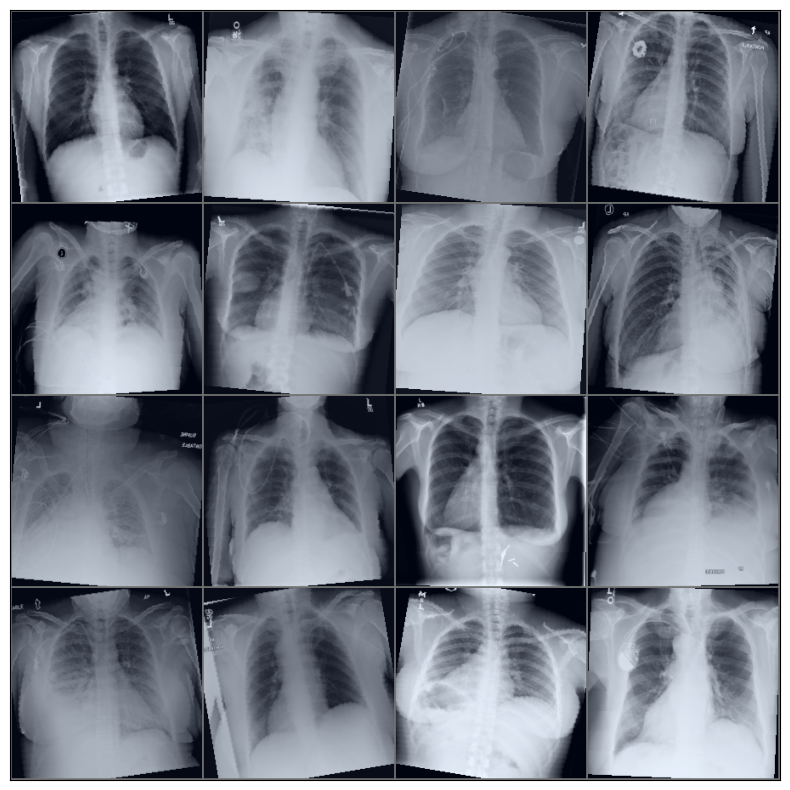

In [ ]:
show_train_dl = DataLoader(train_dataset, batch_size=16, shuffle=True)
show_val_dl = DataLoader(val_dataset, batch_size=16, shuffle=False)
show_test_dl = DataLoader(test_dataset, batch_size=16, shuffle=False)

def Show_Sample(dl):
    _,ax = plt.subplots(figsize=(12,10))
    imgs,labels = next(iter(dl))
    ax.set_yticks([])
    ax.set_xticks([])
    grid = make_grid(imgs, 4).permute(1, 2, 0).numpy()

    grid = (grid - grid.min()) / (grid.max() - grid.min())

    ax.imshow(grid)
    

Show_Sample(show_train_dl)

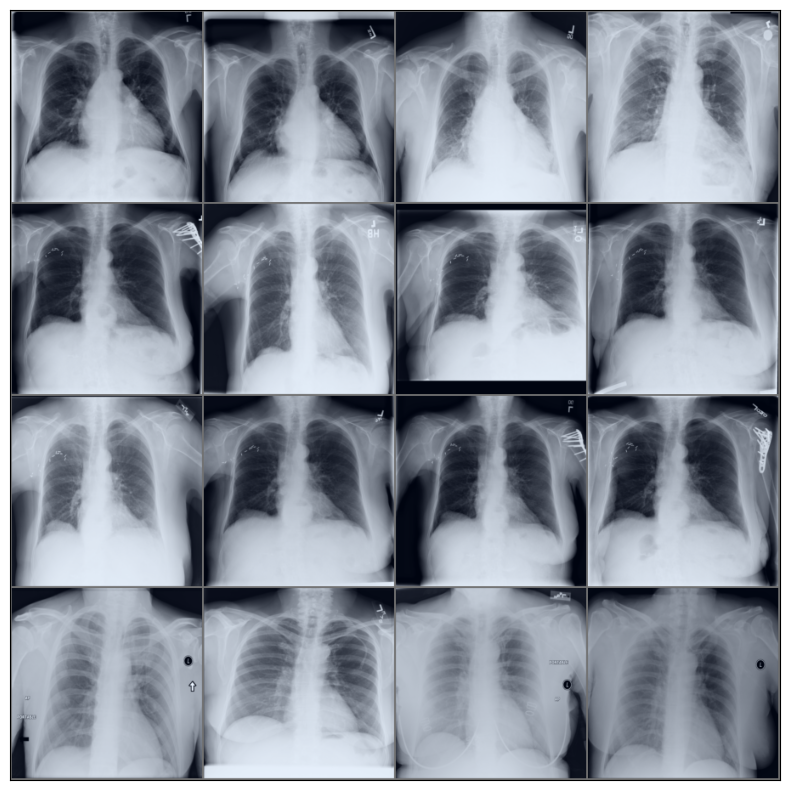

In [ ]:
Show_Sample(show_val_dl)

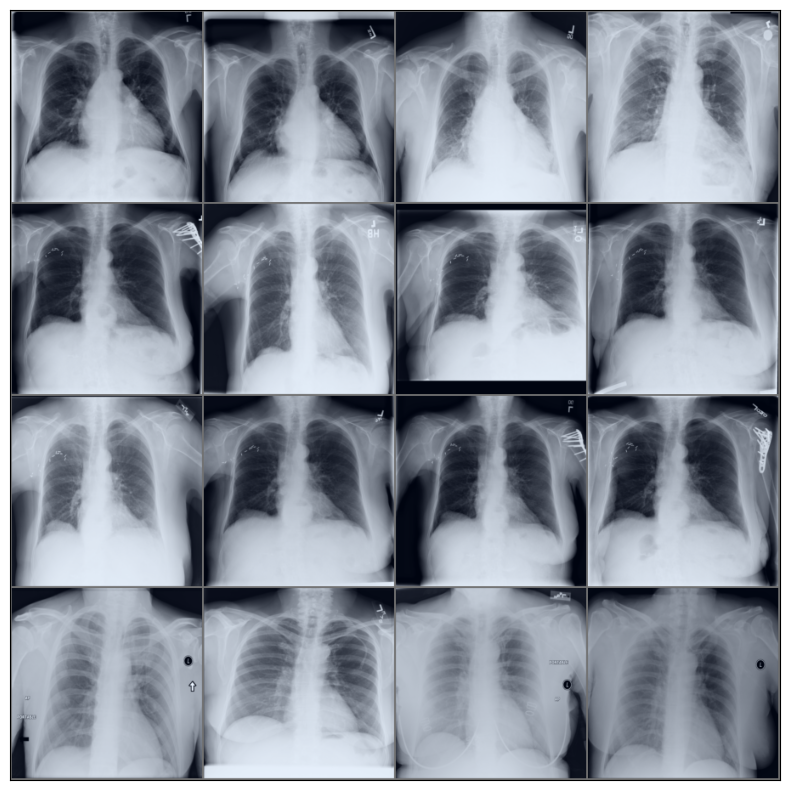

In [ ]:
Show_Sample(show_test_dl)